# «Ставка ЦБ, курс рубля и его волатильность»: сборка результатов

Команда: см. README.

Этот ноутбук последовательно вызывает все скрипты `src/` и показывает
итоговые таблицы и рисунки, которые вошли в презентацию (`slides/`).
Полная инструкция по воспроизведению — в `README.md`.

In [1]:
import subprocess, sys, time
from pathlib import Path

ROOT = Path.cwd()
scripts = [
    "src/00_download.py",
    "src/01_prepare.py",
    "src/02_descriptive.py",
    "src/03_var.py",
    "src/04_garch.py",
    "src/05_robustness.py",
]

t0 = time.time()
for s in scripts:
    print(f"\n=== {s} ===")
    result = subprocess.run([sys.executable, s], cwd=ROOT, capture_output=True, text=True)
    print(result.stdout)
    if result.returncode != 0:
        print(result.stderr)
        raise RuntimeError(f"{s} завершился с ошибкой")
print(f"\nПолный прогон занял {time.time() - t0:.1f} с.")


=== src/00_download.py ===


Скачиваю ключевую ставку: https://www.cbr.ru/hd_base/KeyRate/?UniDbQuery.Posted=True&UniDbQuery.From=01.01.2013&UniDbQuery.To=23.09.2026
Строк: 3264 -> data/raw/keyrate_raw.csv
Скачиваю курс USD/RUB: https://www.cbr.ru/scripts/XML_dynamic.asp?date_req1=01.01.2013&date_req2=23.09.2026&VAL_NM_RQ=R01235
Строк: 3385 -> data/raw/usdrub_raw.csv
Скачиваю Brent (FRED): https://fred.stlouisfed.org/graph/fredgraph.csv?id=DCOILBRENTEU
Строк: 10266 -> data/raw/brent_raw.csv
Загрузка завершена за 2.9 с


=== src/01_prepare.py ===



=== Пересчёт фактов раздела 0 плана ===
Ключевая ставка: 3264 строк, 2013-09-17 .. 2026-09-23
  фактических изменений ставки: 65
  диапазон: 4.25% .. 21.0%
Курс USD/RUB: 3385 строк, 2013-01-10 .. 2026-09-23
  пик: 120.38 на 2022-03-11
Brent: 3581 строк, 2013-01-01 .. 2026-09-22
  последнее значение: 114.9$ на 2026-09-22

Месячная панель: 157 месяцев, 2013-09-30 .. 2026-09-30
Корреляция уровней:
          key_rate  usdrub  brent
key_rate     1.000   0.571  0.134
usdrub       0.571   1.000 -0.140
brent        0.134  -0.140  1.000

=== T2: тесты на стационарность ===
variable transform  adf_stat  adf_p  kpss_stat  kpss_p
key_rate     level    -2.356  0.155      0.676   0.016
key_rate      diff    -8.201  0.000      0.054   0.100
  usdrub     level    -2.646  0.084      1.354   0.010
  usdrub      diff    -8.400  0.000      0.077   0.100
   brent     level    -2.237  0.193      0.302   0.100
   brent      diff    -8.102  0.000      0.250   0.100
Выбор лага VAR по BIC (обоснование в plan_k

=== T1: описание выборки ===
  series  n_obs   date_min   date_max  value_min  value_max  value_mean
key_rate   3264 2013-09-17 2026-09-23       4.25      21.00       10.41
  usdrub   3385 2013-01-10 2026-09-23      29.93     120.38       66.83
   brent   3581 2013-01-01 2026-09-22       9.12     138.21       73.21

Сохранено: /home/sveta/Downloads/EDA_homework/keyrate-volatility/output/figures/R1_three_series.png


=== src/03_var.py ===


Основная спецификация: var_diff, лаг (k_ar_diff)=2

=== T3: выбор лага VAR (по уровням) ===
criterion  selected_lag
      aic             3
      bic             3
     hqic             3
      fpe             3

Модель стабильна: True
Тест на автокорреляцию остатков (whiteness, 12 лагов): p=0.999

=== T4: тест Грейнджера ===
                  spec              control  causing   caused  f_stat  p_value                          conclusion
VAR-в-разностях (осн.)   с нефтью в системе key_rate   usdrub 50.2385   0.0000 отвергаем H0 (есть предсказуемость)
VAR-в-разностях (осн.)   с нефтью в системе   usdrub key_rate  5.3844   0.0049 отвергаем H0 (есть предсказуемость)
VAR-в-разностях (осн.)            без нефти key_rate   usdrub 50.6541   0.0000 отвергаем H0 (есть предсказуемость)
VAR-в-разностях (осн.)            без нефти   usdrub key_rate  5.2425   0.0058 отвергаем H0 (есть предсказуемость)
   VECM (kd=1, rank=1) с нефтью (в системе) key_rate   usdrub 52.3147   0.0000 отвергаем H0 (есть

ARCH-LM тест (H0: нет ARCH-эффекта): p=5.74e-159

=== T5: параметры GARCH(1,1) ===
          period  n_obs  omega  alpha   beta  persistence  ljung_box_resid_p  ljung_box_resid_sq_p
     весь период   3384 0.0425 0.2424 0.7384       0.9807             0.0000                0.6140
   до 28.02.2022   2252 0.0291 0.1942 0.7915       0.9857             0.0516                0.8181
после 28.02.2022   1132 0.0612 0.2909 0.6880       0.9789             0.0000                0.3660

Сохранено: /home/sveta/Downloads/EDA_homework/keyrate-volatility/output/figures/R3_conditional_volatility.png

=== T6: событийное исследование вокруг решений ЦБ ===
 window_days  n_events  observed_abs_return_pct  placebo_abs_return_mean  placebo_abs_return_p95  p_value_abs_return  observed_cond_vol  placebo_cond_vol_mean  placebo_cond_vol_p95  p_value_cond_vol
           5        65                   0.9206                   0.6799                  0.7794                 0.0             1.1574                 0.95

=== T7: робастность (Грейнджер по проверкам) ===
                            check                  variant  n_obs  rate_to_fx_p  fx_to_rate_p                       conclusion
               альтернативный лаг              k_ar_diff=1    156        0.0000        0.0100 оба направления значимы (p<0.05)
               альтернативный лаг   k_ar_diff=2 (основной)    156        0.0000        0.0049 оба направления значимы (p<0.05)
               альтернативный лаг              k_ar_diff=3    156        0.0000        0.0439 оба направления значимы (p<0.05)
подпериод (структурный слом 2022)            до 28.02.2022    100        0.0623        0.0402 не всё значимо / мало наблюдений
подпериод (структурный слом 2022)         после 28.02.2022     55        0.7792        0.0000 не всё значимо / мало наблюдений
              хвост выборки (0.8) полный период (основной)    156        0.0000        0.0049 оба направления значимы (p<0.05)
              хвост выборки (0.8)    без хвоста 07-09.2026    

## Т1. Описание выборки

In [2]:
import pandas as pd
pd.read_csv("output/tables/T1_sample.csv")

,series,n_obs,date_min,date_max,value_min,value_max,value_mean
0,key_rate,3264,2013-09-17,2026-09-23,4.2500,21.0000,10.409620
1,usdrub,3385,2013-01-10,2026-09-23,29.9251,120.3785,66.834540
2,brent,3581,2013-01-01,2026-09-22,9.1200,138.2100,73.210684


## Р1. Три ряда во времени

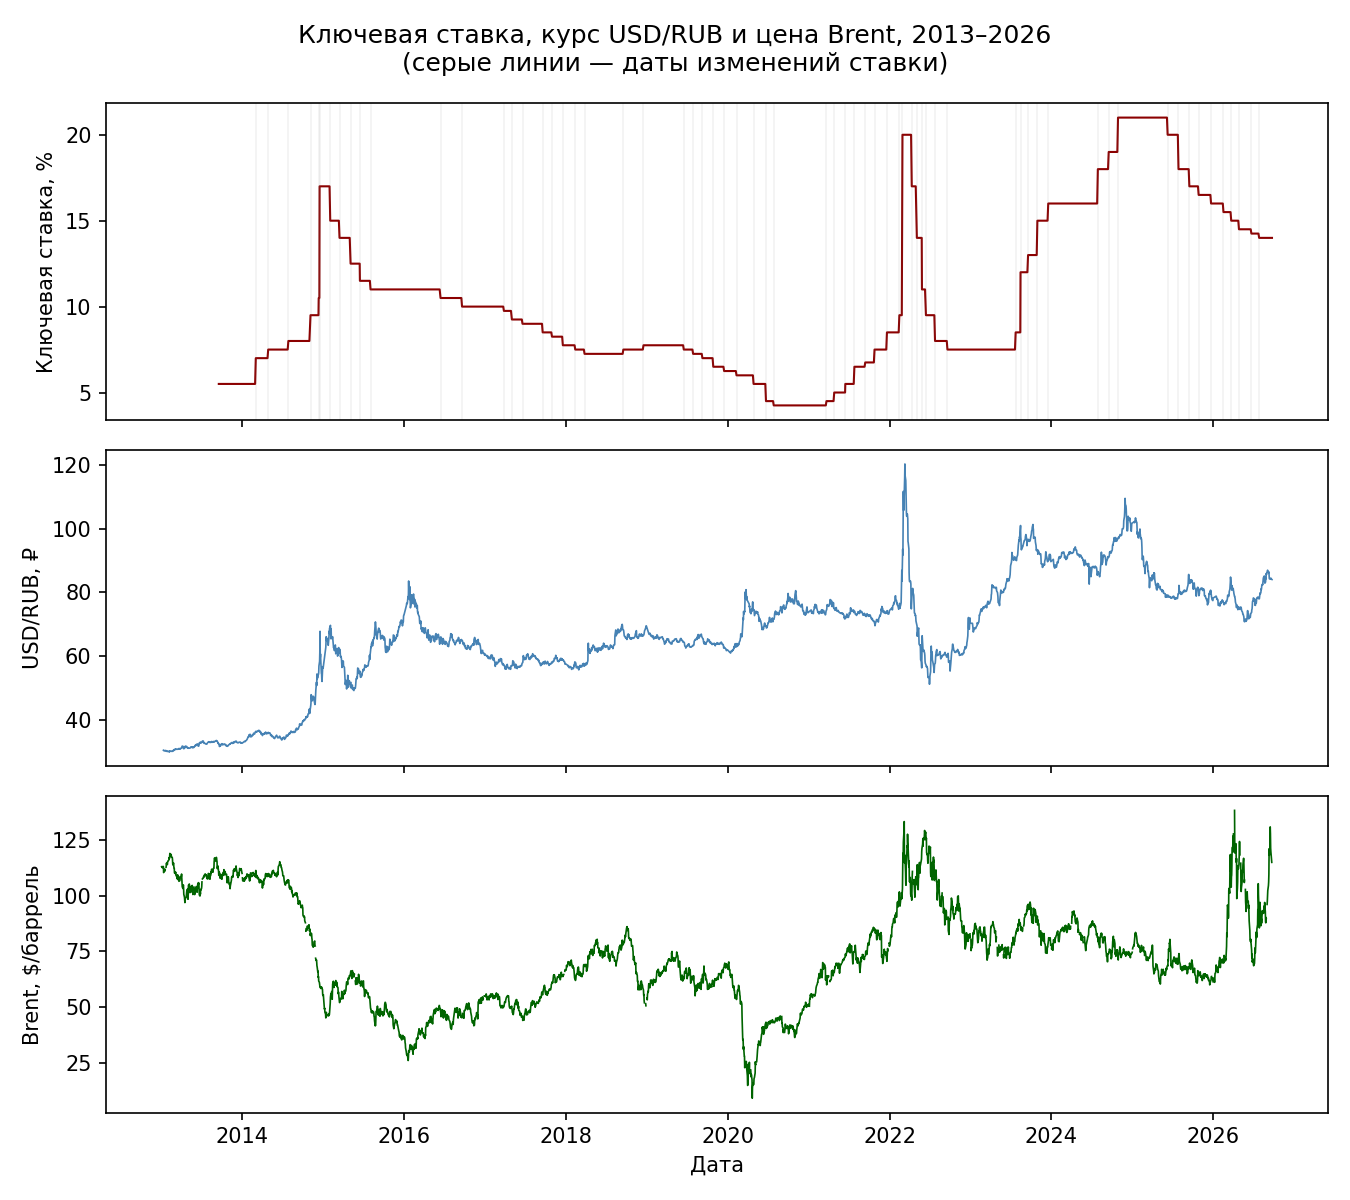

In [3]:
from IPython.display import Image
Image("output/figures/R1_three_series.png")

## Т2. Тесты на стационарность

In [4]:
pd.read_csv("output/tables/T2_stationarity.csv")

,variable,transform,adf_stat,adf_p,kpss_stat,kpss_p
0,key_rate,level,-2.355771,1.546107e-01,0.675690,0.015755
1,key_rate,diff,-8.201187,7.223433e-13,0.053728,0.100000
2,usdrub,level,-2.646131,8.383268e-02,1.354168,0.010000
3,usdrub,diff,-8.400386,2.239667e-13,0.076761,0.100000
4,brent,level,-2.237052,1.930736e-01,0.302288,0.100000
5,brent,diff,-8.101818,1.293734e-12,0.250468,0.100000


## Тест на коинтеграцию и выбор спецификации

Полный протокол решения (чувствительность ранга к лагу) — в `data/processed/var_spec_decision.txt`.

In [5]:
print(Path("data/processed/var_spec_decision.txt").read_text(encoding="utf-8"))

Выбор лага VAR по BIC (обоснование в plan_keyrate.md, п. 0.5): p=3
=> k_ar_diff для VECM/Йохансена = 2

Чувствительность ранга коинтеграции к k_ar_diff (обязательная проверка,
т.к. ранг оказался чувствителен к выбору лага):
  k_ar_diff=1 (trace, 5%): ранг=1
    r<=0: stat=32.49, crit_95=29.80 -> отвергаем H0
    r<=1: stat=14.96, crit_95=15.49 -> не отвергаем H0 (граница, разница <1)
    r<=2: stat=5.58, crit_95=3.84 -> отвергаем H0
  k_ar_diff=2 (trace, 5%): ранг=0
    r<=0: stat=22.54, crit_95=29.80 -> не отвергаем H0
    r<=1: stat=11.57, crit_95=15.49 -> не отвергаем H0
    r<=2: stat=4.32, crit_95=3.84 -> отвергаем H0 (граница, разница <1)
  k_ar_diff=3 (trace, 5%): ранг=0
    r<=0: stat=22.66, crit_95=29.80 -> не отвергаем H0
    r<=1: stat=10.64, crit_95=15.49 -> не отвергаем H0
    r<=2: stat=3.47, crit_95=3.84 -> не отвергаем H0 (граница, разница <1)

Основная спецификация использует лаг, выбранный по данным (k_ar_diff=2), а не произвольный: ранг=0 => var_diff.
ВНИМАНИЕ: ранг 

## Т3. Выбор лага VAR

In [6]:
pd.read_csv("output/tables/T3_lag_selection.csv")

,criterion,selected_lag
0,aic,3
1,bic,3
2,hqic,3
3,fpe,3


## Т4. Тест Грейнджера (полная выборка)

In [7]:
pd.read_csv("output/tables/T4_granger.csv")

,spec,control,causing,caused,f_stat,p_value,conclusion
0,VAR-в-разностях (осн.),с нефтью в системе,key_rate,usdrub,50.238481,2.209645e-20,отвергаем H0 (есть предсказуемость)
1,VAR-в-разностях (осн.),с нефтью в системе,usdrub,key_rate,5.384389,4.894227e-03,отвергаем H0 (есть предсказуемость)
2,VAR-в-разностях (осн.),без нефти,key_rate,usdrub,50.654094,1.156909e-19,отвергаем H0 (есть предсказуемость)
3,VAR-в-разностях (осн.),без нефти,usdrub,key_rate,5.242508,5.785571e-03,отвергаем H0 (есть предсказуемость)
4,"VECM (kd=1, rank=1)",с нефтью (в системе),key_rate,usdrub,52.314677,4.516618e-21,отвергаем H0 (есть предсказуемость)
5,"VECM (kd=1, rank=1)",с нефтью (в системе),usdrub,key_rate,4.924076,7.682670e-03,отвергаем H0 (есть предсказуемость)


## Р2. Импульсный отклик курса на шок ставки

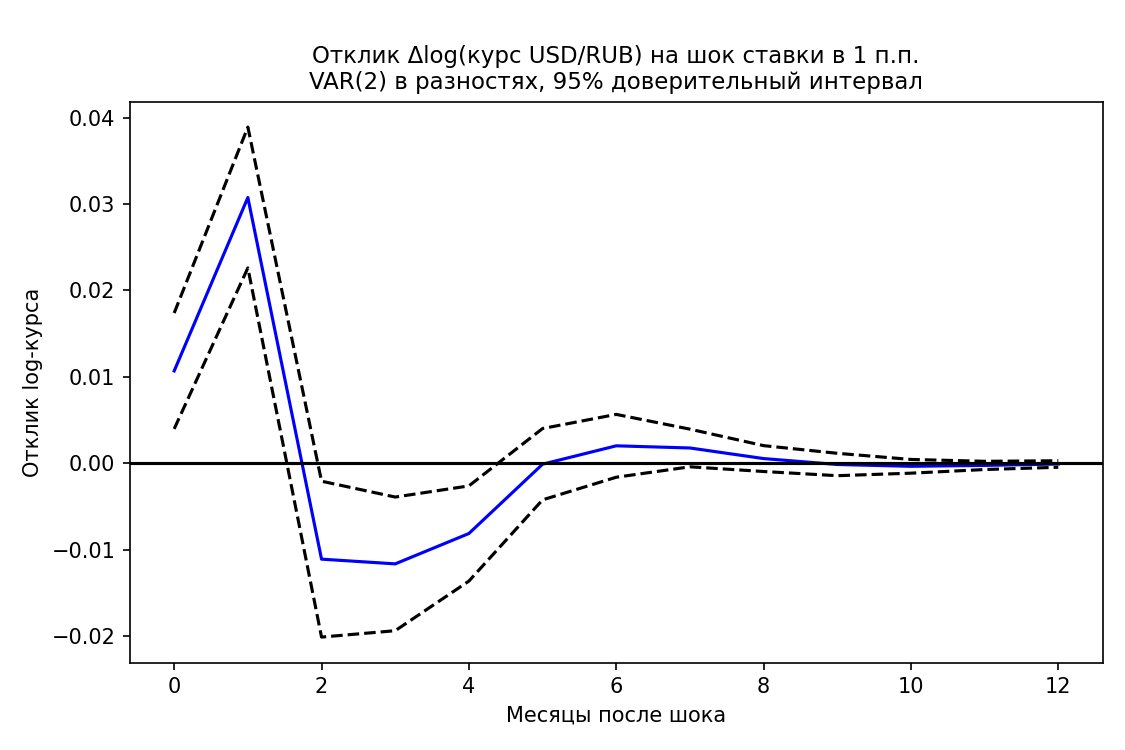

In [8]:
Image("output/figures/R2_irf_rate_to_fx.png")

## Т5. Параметры GARCH(1,1)

In [9]:
pd.read_csv("output/tables/T5_garch.csv")

,period,n_obs,omega,alpha,beta,persistence,ljung_box_resid_p,ljung_box_resid_sq_p
0,весь период,3384,0.042523,0.242381,0.738360,0.980740,1.168681e-10,0.614037
1,до 28.02.2022,2252,0.029120,0.194162,0.791520,0.985682,5.157159e-02,0.818139
2,после 28.02.2022,1132,0.061242,0.290923,0.688022,0.978946,4.007480e-11,0.365998


## Р3. Условная волатильность курса

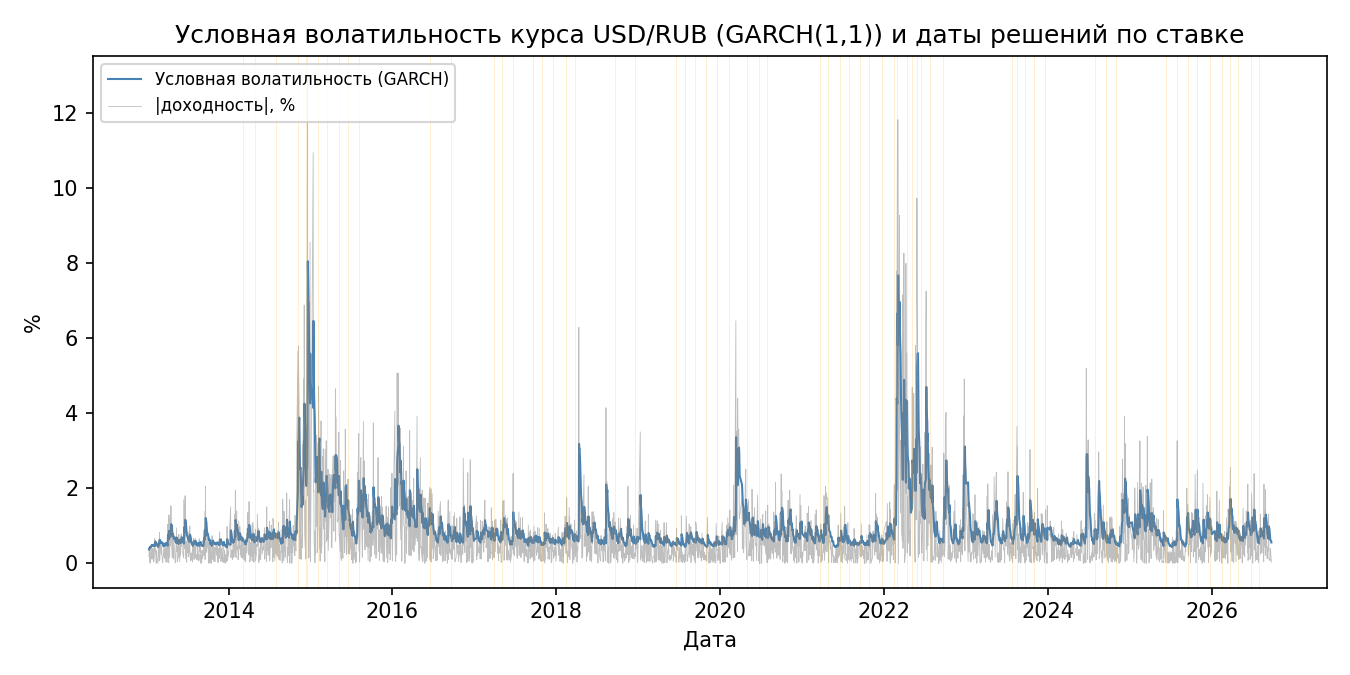

In [10]:
Image("output/figures/R3_conditional_volatility.png")

## Т6. Событийное исследование вокруг решений ЦБ

In [11]:
pd.read_csv("output/tables/T6_event_study.csv")

,window_days,n_events,observed_abs_return_pct,placebo_abs_return_mean,placebo_abs_return_p95,p_value_abs_return,observed_cond_vol,placebo_cond_vol_mean,placebo_cond_vol_p95,p_value_cond_vol
0,5,65,0.920559,0.679863,0.779353,0.0,1.157394,0.953862,1.077903,0.002


## Т7. Робастность

Главный результат этого блока: полновыборочный тест Грейнджера (Т4) не
воспроизводится внутри подпериодов по отдельности — см. строки `check ==
"подпериод (структурный слом 2022)"`. Подробное обсуждение — в
`plan_keyrate.md`, раздел 4, пункт 1.

In [12]:
pd.read_csv("output/tables/T7_robustness.csv")

,check,variant,n_obs,rate_to_fx_p,fx_to_rate_p,conclusion
0,альтернативный лаг,k_ar_diff=1,156,1.480342e-09,0.009975,оба направления значимы (p<0.05)
1,альтернативный лаг,k_ar_diff=2 (основной),156,2.209645e-20,0.004894,оба направления значимы (p<0.05)
2,альтернативный лаг,k_ar_diff=3,156,1.754738e-17,0.043875,оба направления значимы (p<0.05)
3,подпериод (структурный слом 2022),до 28.02.2022,100,6.229590e-02,0.040197,не всё значимо / мало наблюдений
4,подпериод (структурный слом 2022),после 28.02.2022,55,7.791928e-01,0.000008,не всё значимо / мало наблюдений
5,хвост выборки (0.8),полный период (основной),156,2.209645e-20,0.004894,оба направления значимы (p<0.05)
6,хвост выборки (0.8),без хвоста 07-09.2026,153,3.474595e-20,0.004540,оба направления значимы (p<0.05)


## Т7b. Чувствительность IRF к порядку переменных

In [13]:
pd.read_csv("output/tables/T7b_irf_ordering.csv")

,ordering,peak_horizon,peak_value,sign
0,"key_rate, usdrub, brent (основной)",1,0.030752,+
1,"usdrub, key_rate, brent",1,0.025915,+
2,"brent, key_rate, usdrub",1,0.030653,+
